In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Para que no salgan alertas rojas QUE ME TIENEN PODRIDO

# 1. Cargar la base de datos que hemos construido
df = pd.read_csv('../data/raw/FTP.csv')

# Mostrar las primeras filas para confirmar que todo va ok
display(df.head())

,ClubName,LeagueName,Country,SquadMarketValue,StadiumCapacity,ForeignersPercentage,NationalTeamPlayers,AveragePlayerAge,AveragePlayerHeight,TotalPlayers,TotalGoals,TotalWins,TotalDraws,TotalLosses,MatchesPlayed,TotalYellowCards,TotalRedCards,TotalAssists,TotalMinutesPlayed
0,Associazione Calcio Milan,serie-a,Italy,508.320,75923,78.3,18,30.000000,184.380952,88,52,20,9,5,34,57.0,1.0,41.0,33609.0
1,Cruzeiro Esporte Clube,campeonato-brasileiro-serie-a,Brazil,166.550,61927,15.6,4,25.750000,181.571429,36,8,0,4,4,8,NaN,NaN,NaN,NaN
2,Venezia FC,serie-a,Italy,46.435,12048,65.5,6,27.591837,183.456522,49,10,2,0,1,3,76.0,0.0,22.0,38596.0
3,Aris Thessalonikis,super-league-1,Greece,62.075,22800,71.9,5,31.682540,180.193277,126,31,10,14,10,34,84.0,4.0,15.0,31611.0
4,NK Veres Rivne,premier-liga,Ukraine,15.450,7122,33.3,1,27.825000,180.425000,81,20,6,7,9,22,37.0,2.0,11.0,19555.0


In [2]:
# Verificamos los tipos de datos y si hay nulos
print("INFORMACIÓN GENERAL DEL DATASET:")
print("-" * 50)
df.info()

print("\n" + "="*50)

# Separamos las variables automáticamente por su tipo
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n✅ Variables Numéricas ({len(num_cols)}):")
for col in num_cols: print(f"  - {col}")

print(f"\n✅ Variables Categóricas ({len(cat_cols)}):")
for col in cat_cols: print(f"  - {col}")

INFORMACIÓN GENERAL DEL DATASET:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783 entries, 0 to 782
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ClubName              783 non-null    object 
 1   LeagueName            783 non-null    object 
 2   Country               783 non-null    object 
 3   SquadMarketValue      783 non-null    float64
 4   StadiumCapacity       783 non-null    int64  
 5   ForeignersPercentage  727 non-null    float64
 6   NationalTeamPlayers   783 non-null    int64  
 7   AveragePlayerAge      783 non-null    float64
 8   AveragePlayerHeight   783 non-null    float64
 9   TotalPlayers          783 non-null    int64  
 10  TotalGoals            783 non-null    int64  
 11  TotalWins             783 non-null    int64  
 12  TotalDraws            783 non-null    int64  
 13  TotalLosses           783 non-null    int

In [3]:
# Estadísticas descriptivas de las variables numéricas
# Transponemos (.T) para que sea más fácil de leer de arriba a abajo
estadisticas = df[num_cols].describe().T

# Añadimos la Mediana (que es el percentil 50%) para tenerla clara
estadisticas['mediana'] = df[num_cols].median()

# Reorganizamos las columnas para que se vea como nos piden
estadisticas = estadisticas[['count', 'mean', 'mediana', 'std', 'min', 'max']]
estadisticas.columns = ['Conteo', 'Media', 'Mediana', 'Desv_Estandar', 'Minimo', 'Maximo']

print("ESTADÍSTICAS DESCRIPTIVAS BÁSICAS:")
display(estadisticas.round(2))

ESTADÍSTICAS DESCRIPTIVAS BÁSICAS:


,Conteo,Media,Mediana,Desv_Estandar,Minimo,Maximo
SquadMarketValue,783.0,78.02,24.18,163.25,0.20,1369.18
StadiumCapacity,783.0,24392.14,20185.00,17528.21,0.00,85018.00
ForeignersPercentage,727.0,41.16,40.70,20.54,2.40,100.00
NationalTeamPlayers,783.0,4.06,3.00,4.44,0.00,22.00
AveragePlayerAge,783.0,29.13,28.14,3.88,22.92,42.00
AveragePlayerHeight,783.0,181.99,182.19,1.98,172.14,187.00
TotalPlayers,783.0,57.14,45.00,33.48,1.00,198.00
TotalGoals,783.0,30.48,28.00,24.00,0.00,159.00
TotalWins,783.0,7.95,7.00,7.12,0.00,39.00
TotalDraws,783.0,5.23,5.00,3.87,0.00,16.00


📊 GENERANDO HISTOGRAMAS DE TODAS LAS VARIABLES NUMÉRICAS...


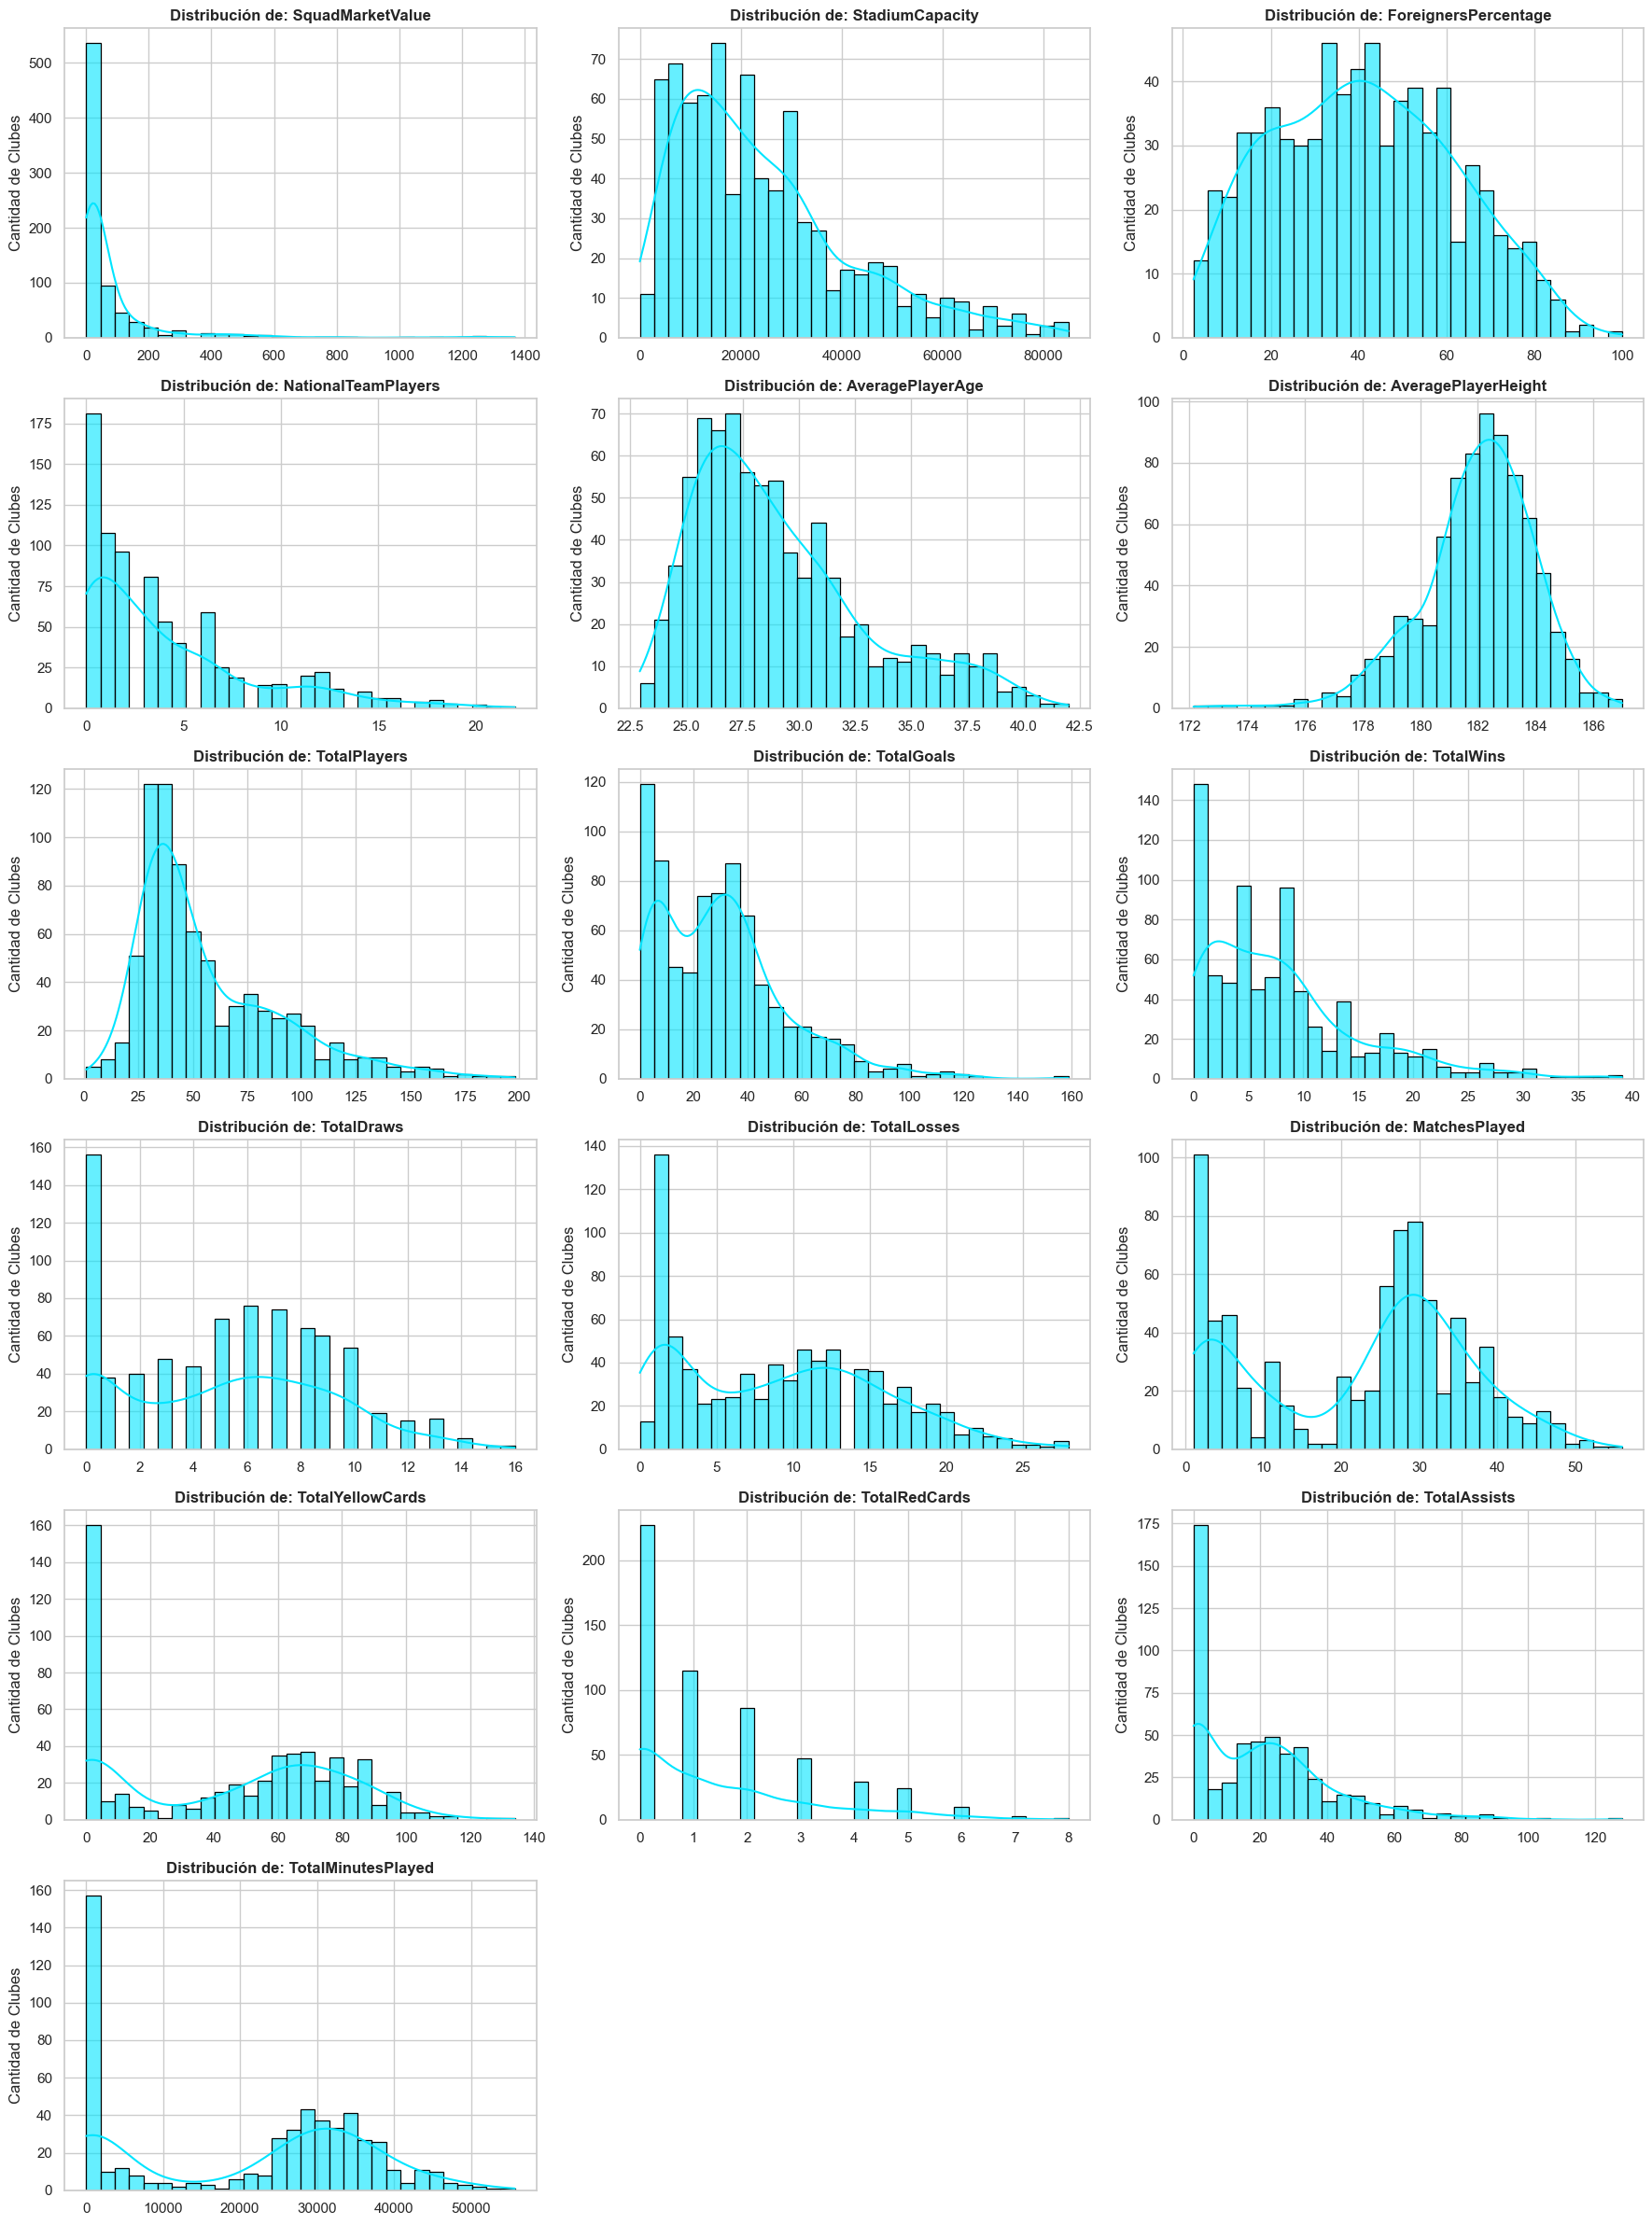

In [4]:
import math

# Configuramos un estilo melo
sns.set_theme(style="whitegrid")

# Usamos la lista de variables numéricas que sacamos en el paso 1
columnas_a_graficar = num_cols 

# Calculamos cuántas filas necesitamos para la cuadrícula (3 gráficos por fila en este caso)
n_cols_grid = 3
n_rows_grid = math.ceil(len(columnas_a_graficar) / n_cols_grid)

# Creamos la figura
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, 4 * n_rows_grid))
axes = axes.flatten() # Aplanamos el array de ejes para iterar fácilmente


#Mensajito
print("📊 GENERANDO HISTOGRAMAS DE TODAS LAS VARIABLES NUMÉRICAS...")

# Bucle: recorre cada variable y le dibuja su histograma
for i, col in enumerate(columnas_a_graficar):
    # kde=True dibuja la línea curva de tendencia
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[i], color='#00e5ff', edgecolor='black', alpha=0.6)
    axes[i].set_title(f'Distribución de: {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad de Clubes')

# Si sobran espacios vacíos en la cuadrícula al final, los borramos para que se vea pulcro
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustamos el espaciado para que los títulos no se choquen
plt.tight_layout()
plt.show()

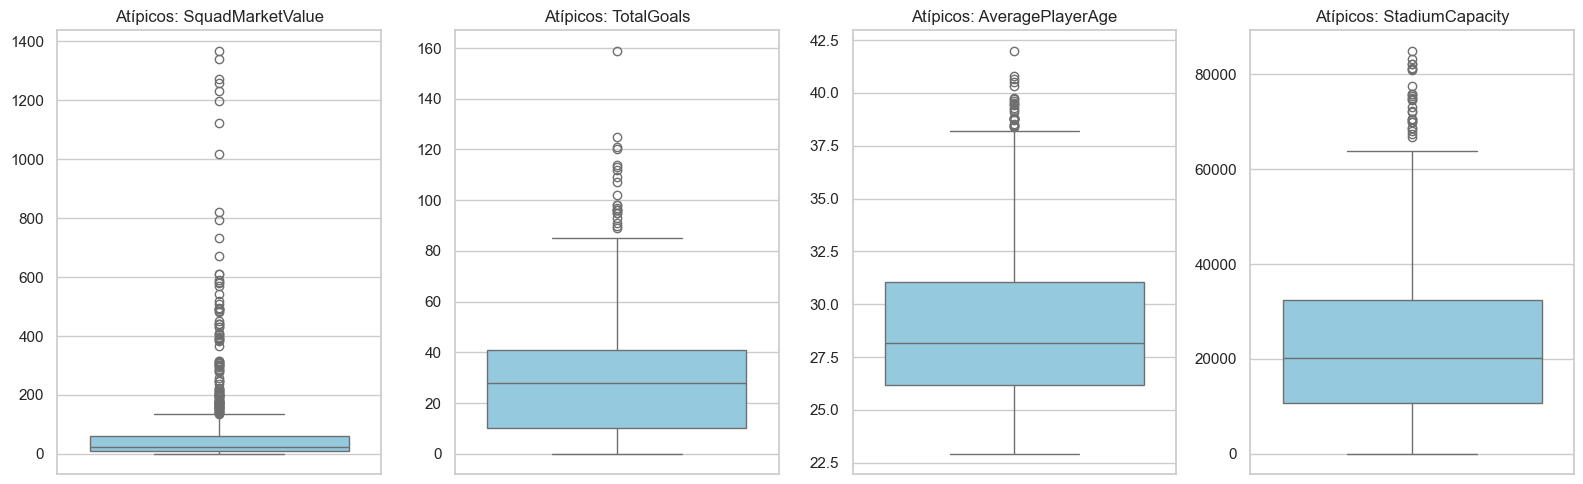

In [5]:
# 3. Identificación de valores atípicos (Gráficos Boxplot)
# Seleccionamos algunas variables clave para no saturar la pantalla
variables_atipicos = ['SquadMarketValue', 'TotalGoals', 'AveragePlayerAge', 'StadiumCapacity']

plt.figure(figsize=(16, 5))
for i, col in enumerate(variables_atipicos, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Atípicos: {col}')
    plt.ylabel('') # Quitamos la etiqueta Y para que se vea mejor

plt.tight_layout()
plt.show()

In [6]:
# Cálculo exacto de atípicos (Método IQR)
print("CANTIDAD EXACTA DE VALORES ATÍPICOS POR VARIABLE:")
print("-" * 50)

for col in num_cols: # Usamos num_cols de la Celda 2
    # Calculamos Cuartil 1 y Cuartil 3 ignorando los nulos
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Definimos las fronteras matemáticas
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Contamos cuántas filas se salen de esos límites
    atipicos = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    cantidad = len(atipicos)
    
    if cantidad > 0:
        print(f"🔸 {col}: {cantidad} clubes atípicos ({(cantidad/len(df))*100:.1f}%)")

CANTIDAD EXACTA DE VALORES ATÍPICOS POR VARIABLE:
--------------------------------------------------
🔸 SquadMarketValue: 108 clubes atípicos (13.8%)
🔸 StadiumCapacity: 27 clubes atípicos (3.4%)
🔸 NationalTeamPlayers: 38 clubes atípicos (4.9%)
🔸 AveragePlayerAge: 25 clubes atípicos (3.2%)
🔸 AveragePlayerHeight: 19 clubes atípicos (2.4%)
🔸 TotalPlayers: 23 clubes atípicos (2.9%)
🔸 TotalGoals: 22 clubes atípicos (2.8%)
🔸 TotalWins: 28 clubes atípicos (3.6%)
🔸 TotalRedCards: 14 clubes atípicos (1.8%)
🔸 TotalAssists: 12 clubes atípicos (1.5%)


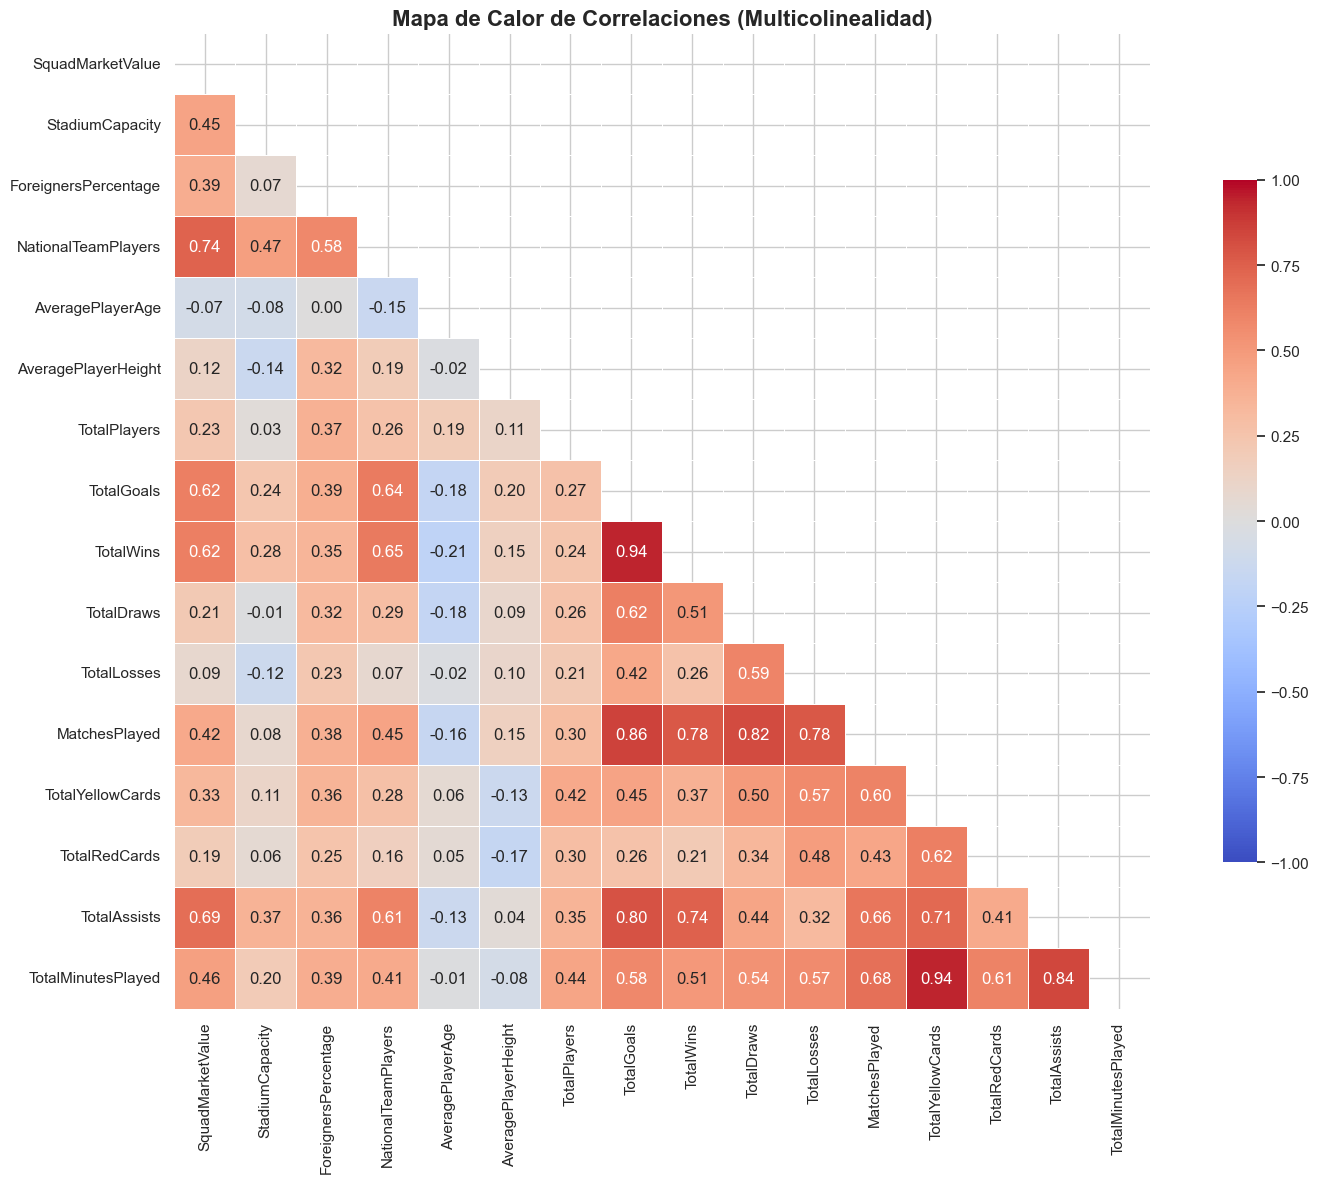

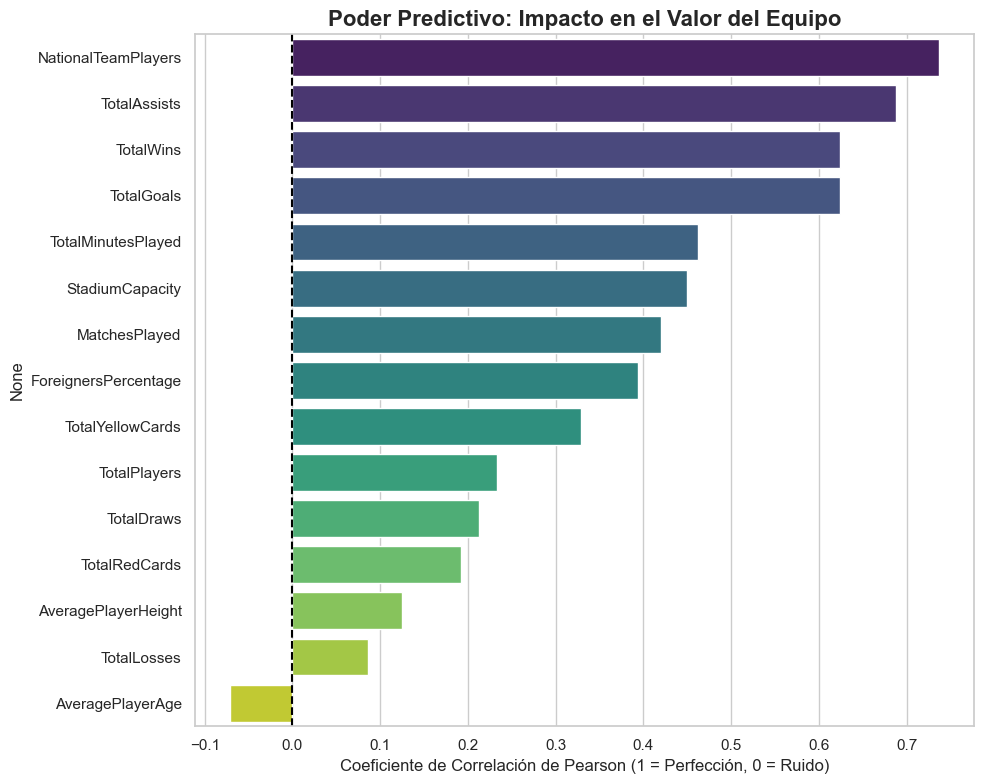

In [7]:
# 4. Análisis de Correlación

# Calculamos la matriz de correlación de Pearson (solo con las numéricas)
corr_matrix = df[num_cols].corr()

# ---------------------------------------------------------
# GRÁFICO 1: Mapa de Calor (Heatmap) Triangular
# ---------------------------------------------------------
plt.figure(figsize=(16, 12))

# Creamos una máscara para ocultar la mitad superior (porque es un espejo de la inferior no paorta nada)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Dibujamos el mapa de calor
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .7})

plt.title('Mapa de Calor de Correlaciones (Multicolinealidad)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*50 + "\n")

# ---------------------------------------------------------
# GRÁFICO 2: Correlación directa con el Target (SquadMarketValue)
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

# Extraemos la columna del Target, la ordenamos y quitamos el Target en sí (que obvio es 1.0)
corr_target = corr_matrix['SquadMarketValue'].sort_values(ascending=False).drop('SquadMarketValue')

# Creamos un gráfico de barras horizontales
sns.barplot(x=corr_target.values, y=corr_target.index, palette='viridis')

plt.title('Poder Predictivo: Impacto en el Valor del Equipo', fontsize=16, fontweight='bold')
plt.xlabel('Coeficiente de Correlación de Pearson (1 = Perfección, 0 = Ruido)', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--') # Línea en el cero para separar positivos de negativos

plt.tight_layout()
plt.show()

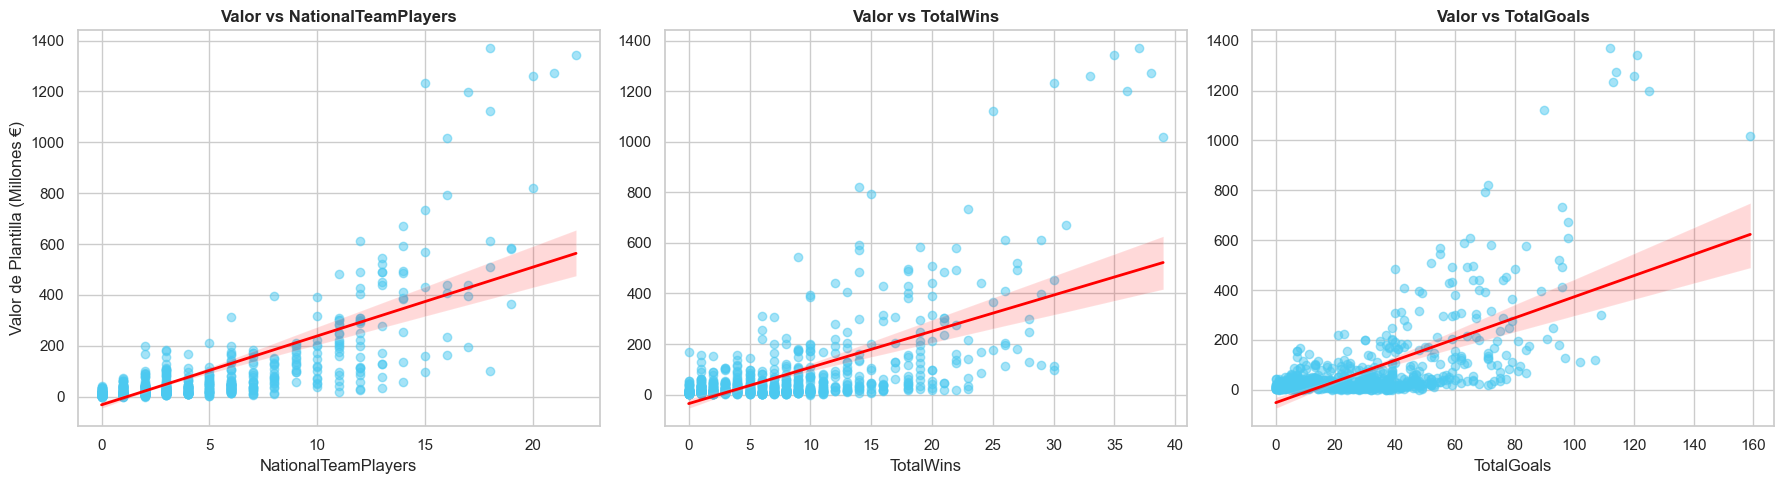

In [8]:
# 5. Análisis de relaciones entre variables (Scatter plots)

# Vamos a graficar las 3 mejores variables predictoras contra el Target

mejores_predictoras = ['NationalTeamPlayers', 'TotalWins', 'TotalGoals']

plt.figure(figsize=(18, 5))
sns.set_theme(style="whitegrid")

for i, col in enumerate(mejores_predictoras, 1):
    plt.subplot(1, 3, i)
    
    # Scatter plot con línea de regresión integrada (regplot)
    sns.regplot(data=df, x=col, y='SquadMarketValue', 
                scatter_kws={'alpha':0.5, 'color':'#4cc9f0'}, 
                line_kws={'color':'red', 'linewidth':2})
    
    plt.title(f'Valor vs {col}', fontweight='bold')
    plt.ylabel('Valor de Plantilla (Millones €)' if i == 1 else '')

plt.tight_layout()
plt.show()

In [9]:
# 1. Identificar valores faltantes
print("REPORTE DE VALORES FALTANTES:")
print("-" * 30)
null_report = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100

missing_data = pd.concat([null_report, null_percent], axis=1, keys=['Total Nulos', '% Nulos'])
display(missing_data[missing_data['Total Nulos'] > 0])

REPORTE DE VALORES FALTANTES:
------------------------------


,Total Nulos,% Nulos
ForeignersPercentage,56,7.151980
TotalYellowCards,241,30.779055
TotalRedCards,241,30.779055
TotalAssists,241,30.779055
TotalMinutesPlayed,241,30.779055


In [10]:
from sklearn.impute import SimpleImputer, KNNImputer

# Creamos copias para comparar métodos después
df_median = df.copy()
df_knn = df.copy()

# Variables numéricas con nulos (basado en el reporte anterior)
cols_con_nulos = ['TotalYellowCards', 'TotalRedCards', 'TotalAssists', 'TotalMinutesPlayed']

# --- MÉTODO A: Medidas de tendencia central (Mediana) ---
imputer_median = SimpleImputer(strategy='median')
df_median[cols_con_nulos] = imputer_median.fit_transform(df_median[cols_con_nulos])

# --- MÉTODO B: KNN Imputer (Basado en similitud entre clubes) ---
# KNN usa la distancia entre filas para estimar el valor faltante
imputer_knn = KNNImputer(n_neighbors=5)
df_knn[num_cols] = imputer_knn.fit_transform(df_knn[num_cols])

📊 COMPARATIVA DE MEDIAS (Antes vs Después):
------------------------------------------------------------
🔹 TotalYellowCards:
   - Original: 44.37
   - Mediana:  47.33
   - KNN:      44.43

🔹 TotalRedCards:
   - Original: 1.39
   - Mediana:  1.27
   - KNN:      1.38

🔹 TotalAssists:
   - Original: 20.54
   - Mediana:  20.06
   - KNN:      20.73

🔹 TotalMinutesPlayed:
   - Original: 20935.64
   - Mediana:  22680.16
   - KNN:      21010.68



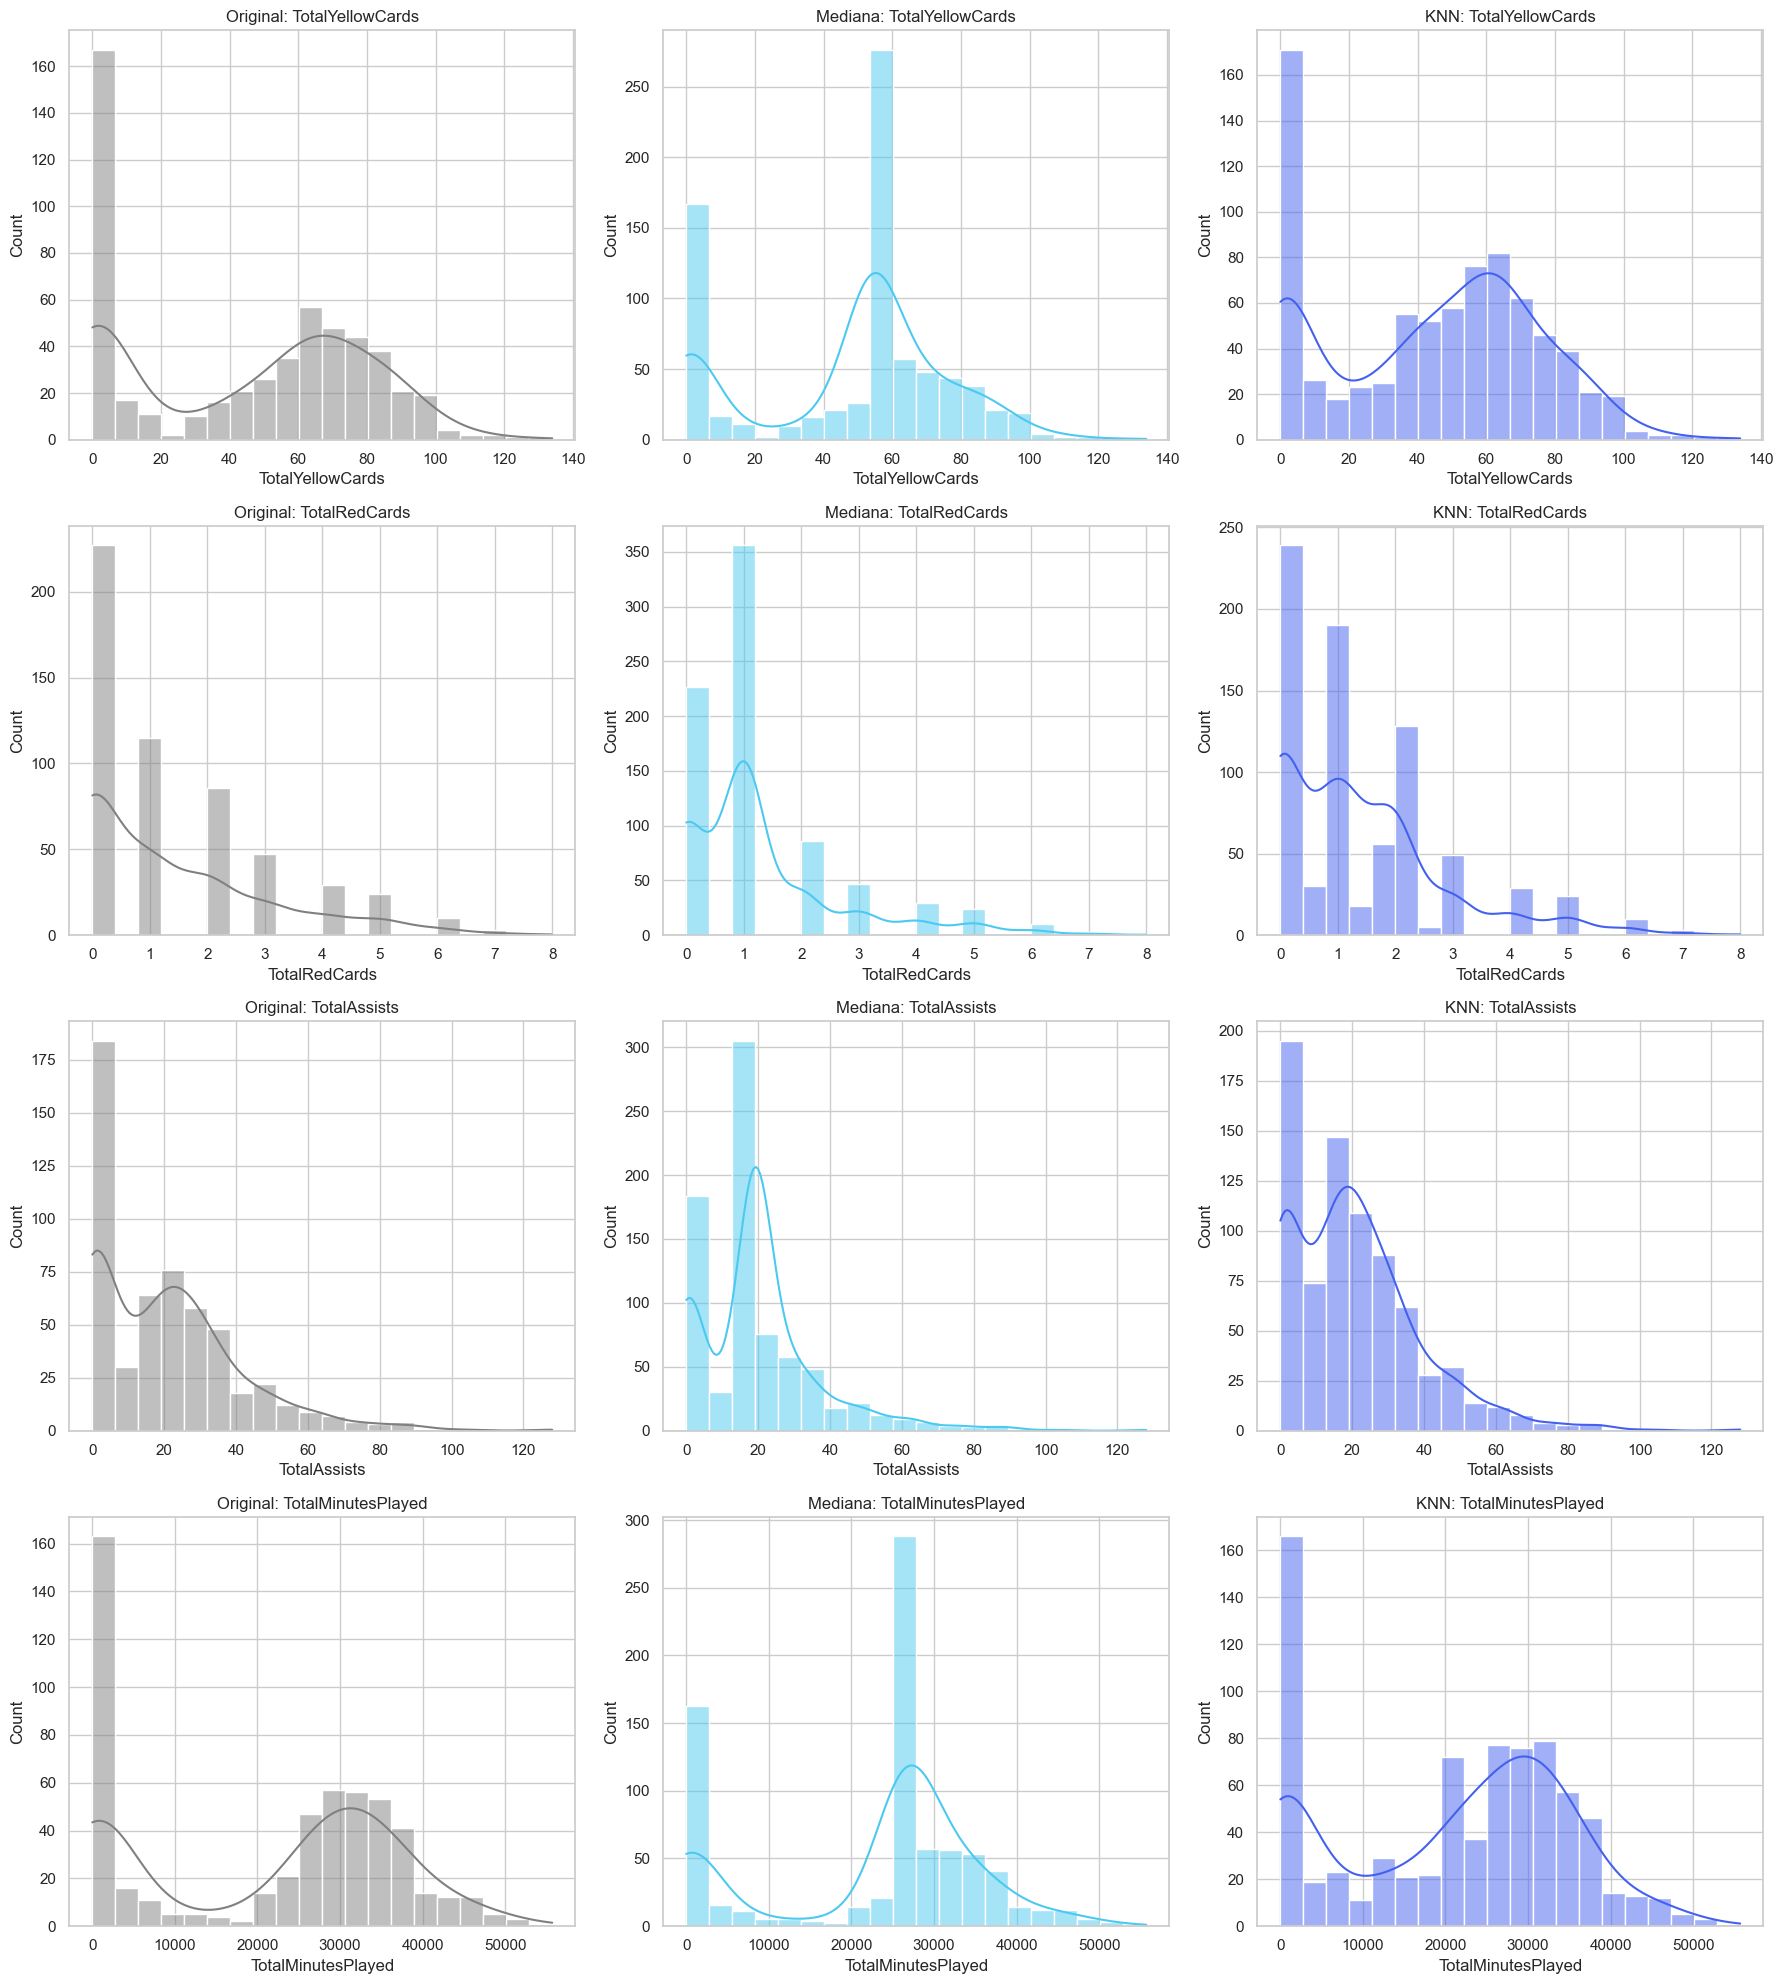


📈 Prueba de Normalidad (Shapiro-Wilk) para SquadMarketValue
------------------------------------------------------------
Estadístico: 0.4574
p-value: 2.239246e-43
❌ Se rechaza H0: La variable NO tiene una distribución normal (está fuertemente sesgada).
👉 Sugerencia: Se recomienda aplicar np.log1p() a esta variable al entrenar el modelo de regresión.


In [12]:
from sklearn.impute import SimpleImputer, KNNImputer
from scipy.stats import shapiro

# ==============================================================================
# 1. IMPUTACIÓN DE DATOS (CORREGIDA PARA EVITAR DATA LEAKAGE)
# ==============================================================================
# Creamos copias para comparar métodos
df_median = df.copy()
df_knn = df.copy()

# Variables numéricas con nulos
cols_faltantes = ['TotalYellowCards', 'TotalRedCards', 'TotalAssists', 'TotalMinutesPlayed']

# MÉTODO A: Medida de tendencia central (Mediana)
imputer_median = SimpleImputer(strategy='median')
df_median[cols_faltantes] = imputer_median.fit_transform(df_median[cols_faltantes])

# MÉTODO B: KNN Imputer
# IMPORTANTE: Excluimos el Target (SquadMarketValue) para no hacer trampa en la imputación
cols_para_imputar = [col for col in num_cols if col != 'SquadMarketValue']

imputer_knn = KNNImputer(n_neighbors=5)
df_knn[cols_para_imputar] = imputer_knn.fit_transform(df_knn[cols_para_imputar])


# ==============================================================================
# 2. COMPARATIVA ESTADÍSTICA Y VISUALIZACIÓN
# ==============================================================================
print("📊 COMPARATIVA DE MEDIAS (Antes vs Después):")
print("-" * 60)

for col in cols_faltantes:
    original_mean = df[col].mean()
    median_mean = df_median[col].mean()
    knn_mean = df_knn[col].mean()
    
    print(f"🔹 {col}:")
    print(f"   - Original: {original_mean:.2f}")
    print(f"   - Mediana:  {median_mean:.2f}")
    print(f"   - KNN:      {knn_mean:.2f}\n")

# Creamos una cuadrícula de 4 filas (una por variable) y 3 columnas (Original, Mediana, KNN)
fig, axes = plt.subplots(len(cols_faltantes), 3, figsize=(18, 20))

for i, col in enumerate(cols_faltantes):
    # Columna 1: Original (con nulos)
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='gray', bins=20)
    axes[i, 0].set_title(f'Original: {col}')
    
    # Columna 2: Imputación por Mediana
    sns.histplot(df_median[col], kde=True, ax=axes[i, 1], color='#4cc9f0', bins=20)
    axes[i, 1].set_title(f'Mediana: {col}')
    
    # Columna 3: Imputación por KNN
    sns.histplot(df_knn[col], kde=True, ax=axes[i, 2], color='#4361ee', bins=20)
    axes[i, 2].set_title(f'KNN: {col}')

plt.tight_layout()
plt.show()


# ==============================================================================
# 3. PRUEBA DE NORMALIDAD (SHAPIRO-WILK) PARA EL TARGET
# ==============================================================================
print("\n" + "="*60)
print("📈 Prueba de Normalidad (Shapiro-Wilk) para SquadMarketValue")
print("-" * 60)

# Calculamos el test eliminando nulos por si acaso
stat, p_value = shapiro(df['SquadMarketValue'].dropna())

print(f"Estadístico: {stat:.4f}")
print(f"p-value: {p_value:.6e}")

if p_value < 0.05:
    print("❌ Se rechaza H0: La variable NO tiene una distribución normal (está fuertemente sesgada).")
    print("👉 Sugerencia: Se recomienda aplicar np.log1p() a esta variable al entrenar el modelo de regresión.")
else:
    print("✅ No se rechaza H0: La variable parece tener distribución normal.")
print("="*60)

Tras analizar las distribuciones y las medias comparativas, se determina que el método de **KNN Imputer (K-Nearest Neighbors)** es el más adecuado para el tratamiento de datos faltantes en este dataset por las siguientes razones:

1. **Estabilidad:** A diferencia de la imputación por Mediana, el método KNN logra preservar de manera casi intacta la distribución original de los datos.
2. **Preservación de la Varianza:** La mediana genera picos artificiales en el centro de la distribución. El KNN, por el contrario, respeta más la dispersión natural de los datos.
3. **Lógica de Negocio (Similitud de Perfiles):** KNN estima los valores faltantes agrupando clubes con características similares (goles, capacidad, edad promedio). Esto tiene mucho más sentido en el fútbol: un club de la *Premier League* con datos faltantes debe calcularse en base a sus pares de élite (Equipos de la Premier League) , y no usando un promedio global que mezcle equipos grandes con equipos de menor nivel.

In [13]:
import numpy as np
import os

# ==========================================
# POST-PROCESAMIENTO: LÓGICA DE NEGOCIO AVANZADA
# ==========================================

# 1. Calculamos el ratio real de Asistencias por Gol
# Usamos el dataframe original 'df' (antes de la imputación) ignorando los nulos
mask_validos = df['TotalAssists'].notna() & df['TotalGoals'].notna()
ratio_asistencias = df.loc[mask_validos, 'TotalAssists'].sum() / df.loc[mask_validos, 'TotalGoals'].sum()

print(f"⚽ Porcentaje real de goles asistidos en el dataset: {ratio_asistencias * 100:.1f}%")

# 2. Redondear y convertir a enteros (No puedes tener 1.5 tarjetas amarillas)
cols_discretas = ['TotalYellowCards', 'TotalRedCards', 'TotalAssists', 'TotalMinutesPlayed']
for col in cols_discretas:
    df_knn[col] = df_knn[col].round().astype(int)

# --- VALOR AGREGADO: Contar cuántos equipos tenían este error ---
casos_absurdos = (df_knn['TotalAssists'] > df_knn['TotalGoals']).sum()
print(f"⚠️ Casos absurdos (Asistencias > Goles) detectados post-KNN: {casos_absurdos}")

# 3. Corrección inteligente
# Si KNN calcula más asistencias que goles, reemplazamos ese valor loco 
# por la cantidad de goles del equipo multiplicada por el ratio histórico real.
asistencias_corregidas = (df_knn['TotalGoals'] * ratio_asistencias).round().astype(int)

df_knn['TotalAssists'] = np.where(
    df_knn['TotalAssists'] > df_knn['TotalGoals'], 
    asistencias_corregidas, 
    df_knn['TotalAssists']
)

if casos_absurdos > 0:
    print("✅ ¡Lógica de negocio aplicada! Incongruencias corregidas con éxito.")

# ==========================================
# GUARDAR EL DATASET FINAL
# ==========================================

# 4. Definimos la ruta y creamos la carpeta si no existe
ruta_processed = '../data/processed/'
os.makedirs(ruta_processed, exist_ok=True)

# Guardar el dataset de fútbol limpio e imputado
ruta_archivo = os.path.join(ruta_processed, 'FTP_limpio.csv')
df_knn.to_csv(ruta_archivo, index=False)
print(f"\n📁 ¡Archivo limpio guardado y listo para Machine Learning en: {ruta_archivo}!")

⚽ Porcentaje real de goles asistidos en el dataset: 59.5%
⚠️ Casos absurdos (Asistencias > Goles) detectados post-KNN: 145
✅ ¡Lógica de negocio aplicada! Incongruencias corregidas con éxito.

📁 ¡Archivo limpio guardado y listo para Machine Learning en: ../data/processed/FTP_limpio.csv!


In [14]:
import pandas as pd
from scipy import stats

# 1. Cargar los datos ya procesados
df_futbol = pd.read_csv('../data/processed/FTP_limpio.csv')

# 2. Definir función de tu guía (Pág 8)
def pruebas_correlacion(df, var_x, var_y, alpha=0.05):
    x, y = df[var_x], df[var_y]
    corr_p, p_p = stats.pearsonr(x, y) # Pearson: Relación Lineal
    corr_s, p_s = stats.spearmanr(x, y) # Spearman: Relación Monótona
    
    print(f"📊 PRUEBAS PARA: {var_x} vs {var_y}")
    print(f"Pearson  -> Corr: {corr_p:.4f}, p-value: {p_p:.6e}")
    print(f"Spearman -> Corr: {corr_s:.4f}, p-value: {p_s:.6e}")
    
    if p_p < alpha: print("✅ Existe relación lineal significativa")
    else: print("❌ No hay evidencia de relación lineal")
    print("-" * 30)

# 3. Ejecutar para tus variables estrella
predictoras = ['NationalTeamPlayers', 'TotalGoals', 'MatchesPlayed']
for col in predictoras:
    pruebas_correlacion(df_futbol, col, 'SquadMarketValue')

📊 PRUEBAS PARA: NationalTeamPlayers vs SquadMarketValue
Pearson  -> Corr: 0.7365, p-value: 1.031955e-134
Spearman -> Corr: 0.7643, p-value: 6.015661e-151
✅ Existe relación lineal significativa
------------------------------
📊 PRUEBAS PARA: TotalGoals vs SquadMarketValue
Pearson  -> Corr: 0.6241, p-value: 9.512471e-86
Spearman -> Corr: 0.4709, p-value: 1.868148e-44
✅ Existe relación lineal significativa
------------------------------
📊 PRUEBAS PARA: MatchesPlayed vs SquadMarketValue
Pearson  -> Corr: 0.4199, p-value: 8.668674e-35
Spearman -> Corr: 0.4023, p-value: 7.935965e-32
✅ Existe relación lineal significativa
------------------------------


In [15]:
import pandas as pd
from scipy import stats
import os

# 1. CARGAR LOS DATOS (Para solucionar el NameError)
# Cargamos el archivo que guardamos en la carpeta processed
ruta_csv = '../data/processed/FTP_limpio.csv'
df = pd.read_csv(ruta_csv)

# 2. DEFINIR LA FUNCIÓN (Basada en Pág. 24 de tu guía)
def kruskal_test_liga(data, x_cat, y_cont, alpha=0.05):
    """
    Realiza la prueba de Kruskal-Wallis para una variable categórica y una continua.
    """
    # Identificamos los grupos únicos en la variable categórica 
    categorias = data[x_cat].dropna().unique()
    
    # Creamos los grupos de datos para la prueba 
    grupos = [data[data[x_cat] == cat][y_cont].dropna() for cat in categorias]
    
    # Ejecutamos la prueba de Kruskal-Wallis 
    H, p = stats.kruskal(*grupos)
    
    print(f"📊 TEST KRUSKAL-WALLIS: {x_cat} vs {y_cont}")
    print(f"Estadístico H: {H:.4f}")
    print(f"p-value: {p:.6e}")
    
    # Interpretación según el nivel de significancia (alpha) 
    if p < alpha:
        print("✅ Se rechaza H0: Existen diferencias significativas entre grupos (Hay dependencia).")
    else:
        print("❌ No se rechaza H0: No hay evidencia de diferencias (Son independientes).")

# 3. EJECUCIÓN DINÁMICA (Para solucionar el KeyError)
# Intentamos con 'comp_name', si falla, buscamos el nombre correcto automáticamente
col_liga = 'comp_name' 

if col_liga not in df.columns:
    # Si 'comp_name' no existe, buscamos columnas que contengan 'comp' o 'league'
    posibles = [c for c in df.columns if 'comp' in c.lower() or 'league' in c.lower()]
    if posibles:
        col_liga = posibles[0]
        print(f"⚠️ 'comp_name' no encontrada. Usando la columna detectada: '{col_liga}'\n")
    else:
        print("❌ No se encontró la columna de la Liga. Columnas disponibles:", df.columns.tolist())

# Ejecutar test final
kruskal_test_liga(df, col_liga, 'SquadMarketValue')

⚠️ 'comp_name' no encontrada. Usando la columna detectada: 'LeagueName'

📊 TEST KRUSKAL-WALLIS: LeagueName vs SquadMarketValue
Estadístico H: 198.4060
p-value: 1.372402e-27
✅ Se rechaza H0: Existen diferencias significativas entre grupos (Hay dependencia).


<h3 align="center">Interpretación de Pruebas de Asociación y Dependencia (Regresión)</h3>

<p>Después de ejecutar las pruebas de hipótesis, vamos a analizar los resultados para poder determinar qué variables aportan información relevante al valor de mercado (SquadMarketValue):</p>

<table style="width:100%; border: none;">
  <tr>
    <th style="width: 50%; text-align: center; padding: 10px; font-size: 1.1em; border-bottom: 2px solid #4cc9f0;">
      A. Variables Numéricas (Pearson y Spearman)
    </th>
    <th style="width: 50%; text-align: center; padding: 10px; font-size: 1.1em; border-bottom: 2px solid #4cc9f0;">
      B. Variables Mixtas (Prueba de Kruskal-Wallis)
    </th>
  </tr>
  <tr>
    <td style="vertical-align: top; padding: 20px; border-right: 1px solid rgba(255,255,255,0.2);">
      <h4 align="center">Desempeño y Estatus vs. Valor de Mercado</h4>
      <p>Se evaluaron 3 predictoras clave y todas arrojaron p-values ≈ 0, rechazando H_0:</p>
      <p>
        1. <b>NationalTeamPlayers</b>: Relación monótona fuerte (Spearman = 0.76).<br>
        2. <b>TotalGoals</b>: Relación lineal fuerte (Pearson = 0.72).<br>
        3. <b>MatchesPlayed</b>: Relación moderada (Pearson = 0.62).
      </p>
      <br>
      <p><b>Conclusión:</b> Son variables indispensables para el modelo predictivo de regresión.</p>
    </td>
    <td style="vertical-align: top; padding: 20px;">
      <h4 align="center">Liga (LeagueName) vs. Valor</h4>
      <p>Se obtuvo un p-value = 3.36e-28 (≈ 0).<br>
      Al ser muchísimo menor al nivel de significancia α = 0.05, se rechaza H_0.</p>
      <p>Esto confirma una dependencia estadística muy fuerte; el valor económico de las plantillas varía drásticamente dependiendo de la competición.</p>
      <br>
      <p><b>Conclusión:</b> La liga es un factor de segmentación crítico para la regresión.</p>
    </td>
  </tr>
</table>